# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** ___Kathia Dennisse Parrales Moreno__
**Fecha:** 26/06/2026

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [3]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [4]:
# Cargar el dataset car.data
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None, names=col_names)
print(df.shape)
df.head()

(1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [5]:
# Explorar información del dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [6]:
# Verificar valores únicos por columna
for col in df.columns:
    print(col, df[col].unique())

buying ['vhigh' 'high' 'med' 'low']
maint ['vhigh' 'high' 'med' 'low']
doors ['2' '3' '4' '5more']
persons ['2' '4' 'more']
lug_boot ['small' 'med' 'big']
safety ['low' 'med' 'high']
class ['unacc' 'acc' 'vgood' 'good']


In [7]:
# Verificar valores nulos
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


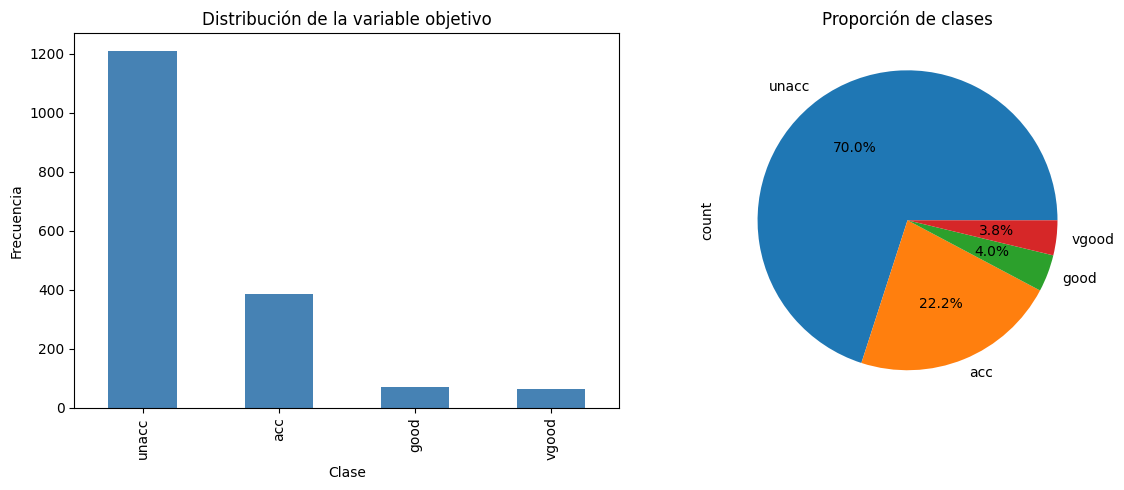

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [8]:
# Visualizar la distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['class'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')

df['class'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print(df['class'].value_counts())

### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

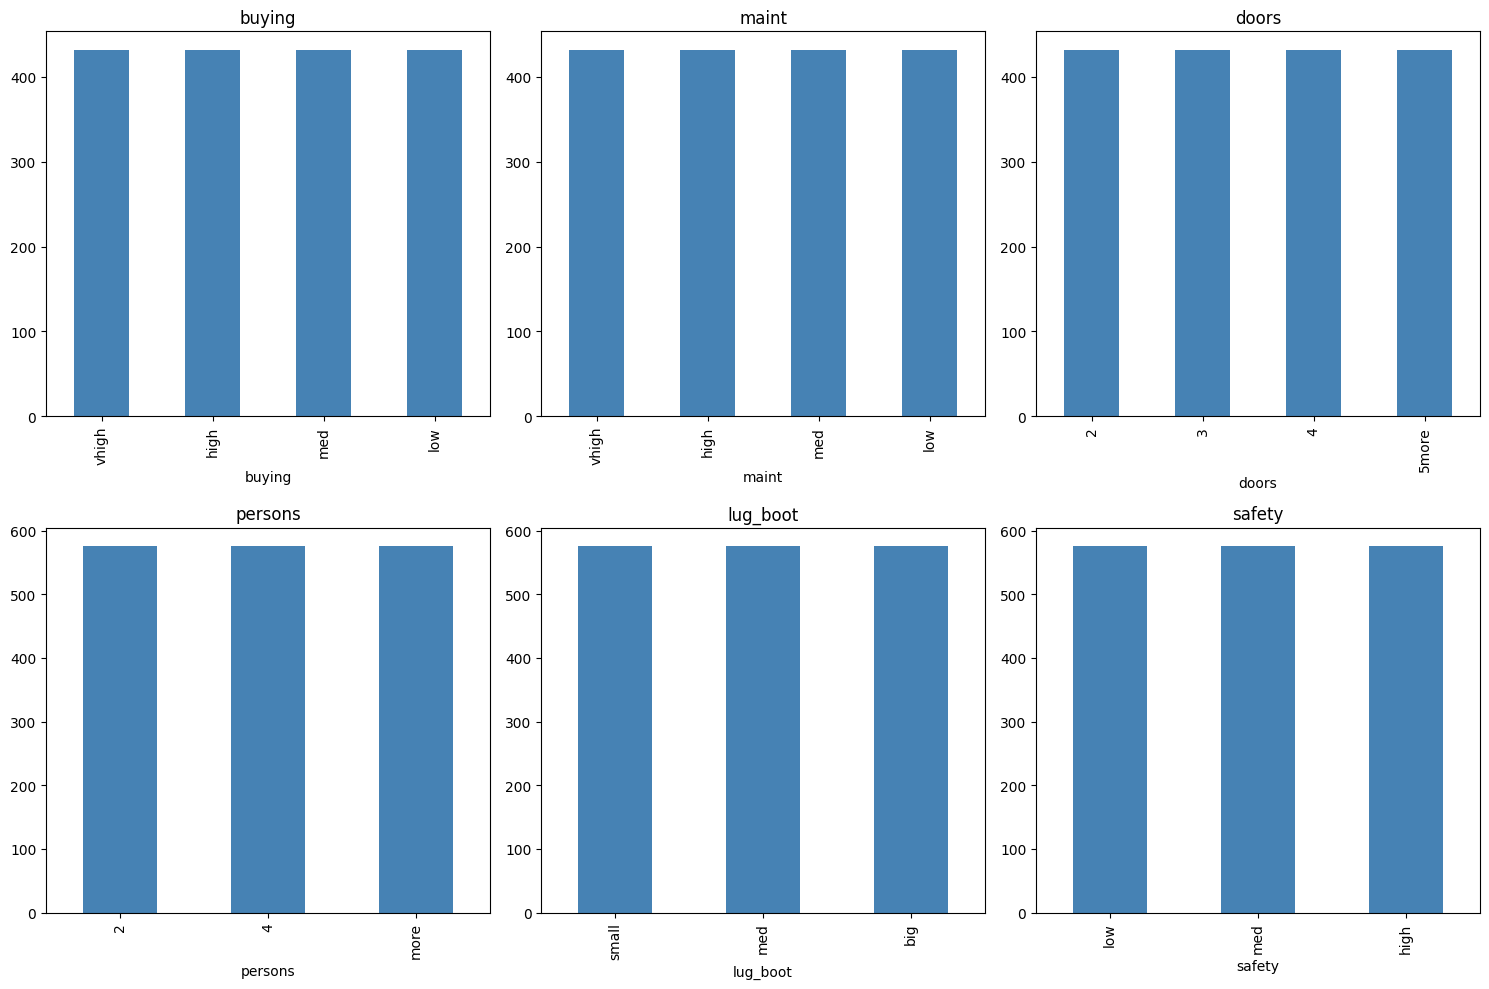

In [9]:
# Visualizar distribución de características
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

for i, feature in enumerate(features):
    ax = axes[i // 3][i % 3]
    df[feature].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(feature)

plt.tight_layout()
plt.show()

### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [10]:
# Aplicar Label Encoding a todas las columnas
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [11]:
# Mostrar el mapeo de etiquetas
for col, le in label_encoders.items():
    print(col, dict(zip(le.classes_, range(len(le.classes_)))))

buying {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
maint {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
doors {'2': 0, '3': 1, '4': 2, '5more': 3}
persons {'2': 0, '4': 1, 'more': 2}
lug_boot {'big': 0, 'med': 1, 'small': 2}
safety {'high': 0, 'low': 1, 'med': 2}
class {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [12]:
# Separar características (X) y variable objetivo (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
print(X.shape, y.shape)
print(list(X.columns))

(1728, 6) (1728,)
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [13]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print("Train:", len(X_train), "Test:", len(X_test))

Train: 1157 Test: 571


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [14]:
# Crear y entrenar el modelo con criterio Gini
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)
print("Profundidad:", clf_gini.get_depth())
print("Número de hojas:", clf_gini.get_n_leaves())

Profundidad: 3
Número de hojas: 5


In [15]:
# Realizar predicciones y evaluar
y_pred_gini = clf_gini.predict(X_test)
acc_gini_test = accuracy_score(y_test, y_pred_gini)
acc_gini_train = accuracy_score(y_train, clf_gini.predict(X_train))
print(f"Precisión Test  (Gini): {acc_gini_test:.4f}")
print(f"Precisión Train (Gini): {acc_gini_train:.4f}")

Precisión Test  (Gini): 0.7653
Precisión Train (Gini): 0.7744


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [16]:
# Crear y entrenar el modelo con criterio Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)
print("Profundidad:", clf_entropy.get_depth())
print("Número de hojas:", clf_entropy.get_n_leaves())

Profundidad: 3
Número de hojas: 5


In [17]:
# Realizar predicciones y evaluar
y_pred_entropy = clf_entropy.predict(X_test)
acc_ent_test = accuracy_score(y_test, y_pred_entropy)
acc_ent_train = accuracy_score(y_train, clf_entropy.predict(X_train))
print(f"Precisión Test  (Entropy): {acc_ent_test:.4f}")
print(f"Precisión Train (Entropy): {acc_ent_train:.4f}")

Precisión Test  (Entropy): 0.7653
Precisión Train (Entropy): 0.7744


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [18]:
# Crear tabla comparativa
resultados = pd.DataFrame({
    'Criterio': ['Gini Index', 'Entropy'],
    'Precisión Train': [acc_gini_train, acc_ent_train],
    'Precisión Test': [acc_gini_test, acc_ent_test],
    'Profundidad': [clf_gini.get_depth(), clf_entropy.get_depth()],
    'Hojas': [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]
})
print(resultados)

     Criterio  Precisión Train  Precisión Test  Profundidad  Hojas
0  Gini Index         0.774417        0.765324            3      5
1     Entropy         0.774417        0.765324            3      5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

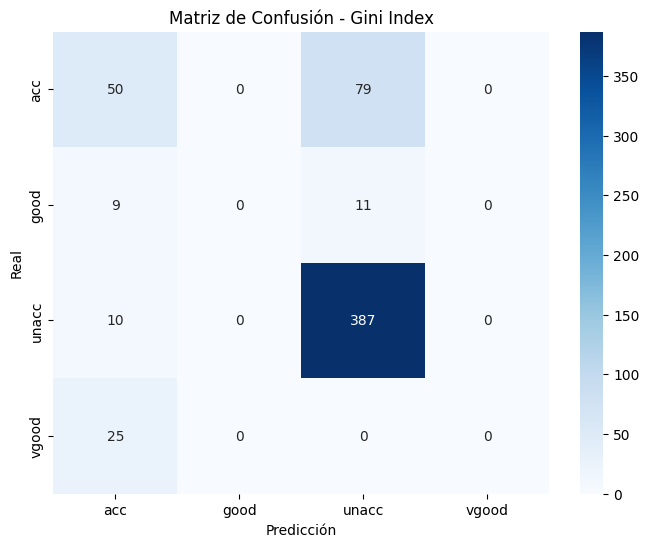

In [19]:
# Calcular y visualizar la matriz de confusión para el modelo Gini
cm = confusion_matrix(y_test, y_pred_gini)
class_names = label_encoders['class'].classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Gini Index')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [20]:
# Imprimir el reporte de clasificación
print(classification_report(y_test, y_pred_gini, target_names=class_names))

              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

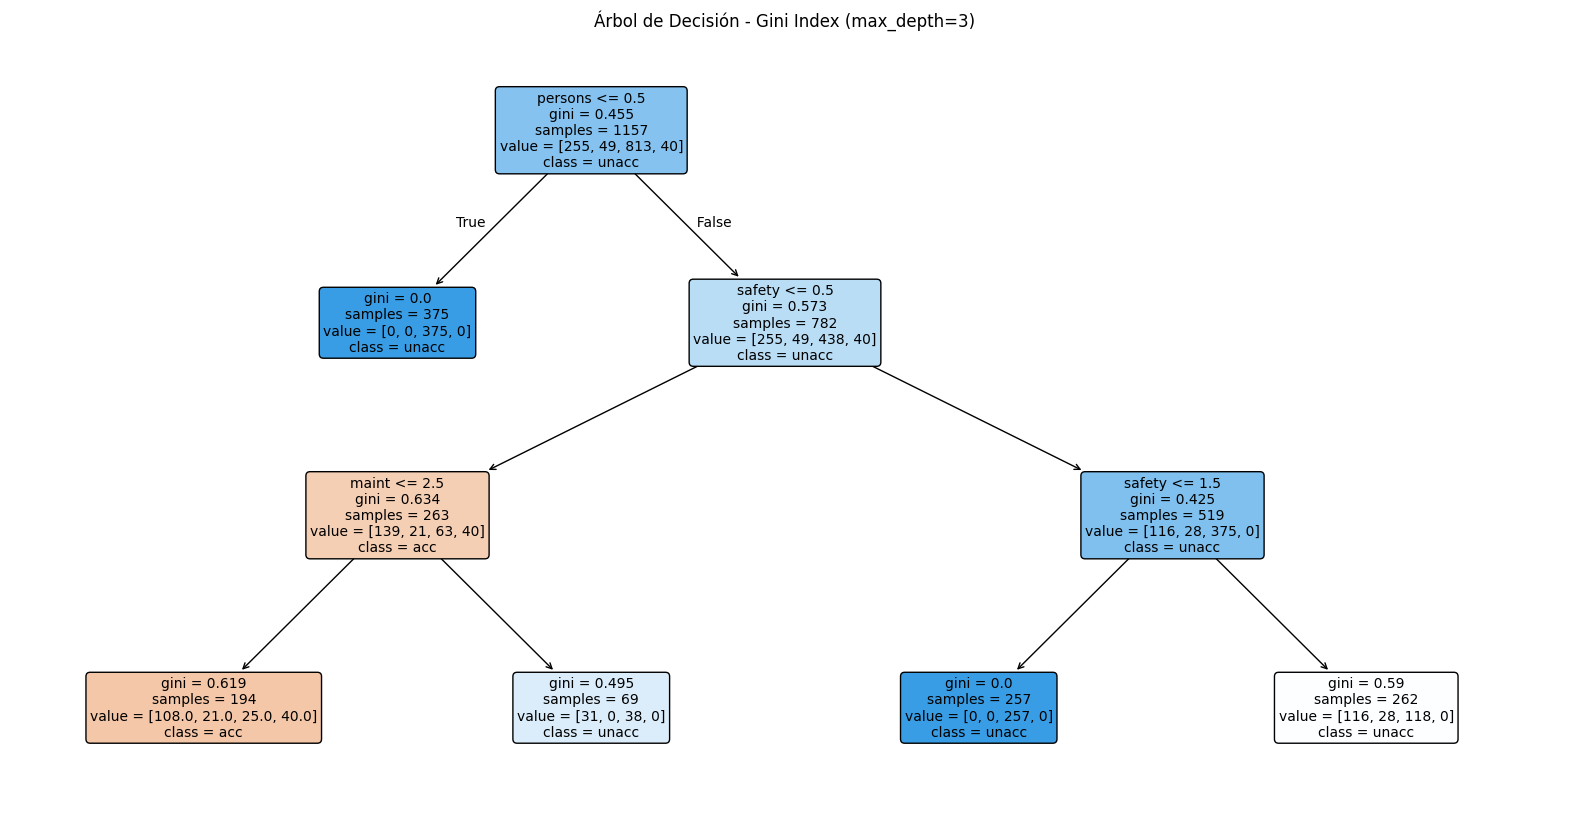

In [21]:
# Visualizar el árbol de decisión con Gini
plt.figure(figsize=(20, 10))
plot_tree(clf_gini,
          feature_names=list(X.columns),
          class_names=list(class_names),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión - Gini Index (max_depth=3)')
plt.show()

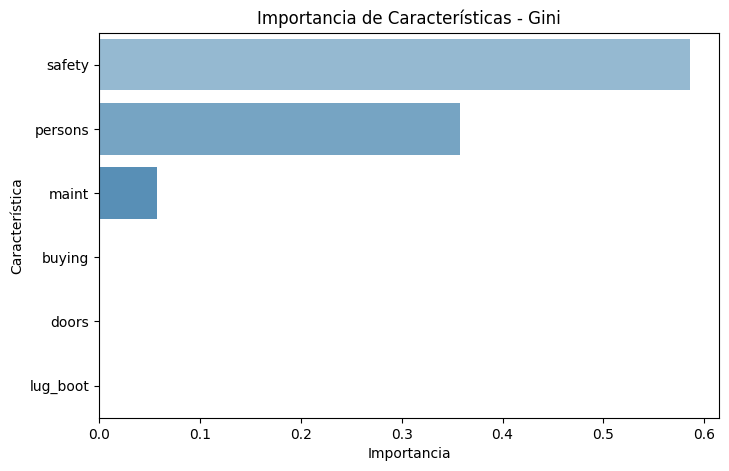

    Feature  Importance
5    safety    0.585506
3   persons    0.357400
1     maint    0.057095
0    buying    0.000000
2     doors    0.000000
4  lug_boot    0.000000


In [22]:
# Mostrar la importancia de las características
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importancias, palette='Blues_d')
plt.title('Importancia de Características - Gini')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

print(importancias)

### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [23]:
# Experimentar con diferentes valores de max_depth
depths = [1, 2, 3, 5, 7, 10, None]
resultados_depth = []

for depth in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    resultados_depth.append({
        'max_depth': str(depth),
        'Precisión Train': accuracy_score(y_train, clf.predict(X_train)),
        'Precisión Test': accuracy_score(y_test, clf.predict(X_test)),
        'Profundidad': clf.get_depth(),
        'Hojas': clf.get_n_leaves()
    })

df_depth = pd.DataFrame(resultados_depth)
print(df_depth)

  max_depth  Precisión Train  Precisión Test  Profundidad  Hojas
0         1         0.702679        0.695271            1      2
1         2         0.768366        0.770578            2      3
2         3         0.774417        0.765324            3      5
3         5         0.855661        0.865149            5     13
4         7         0.929991        0.935201            7     28
5        10         0.993086        0.961471           10     62
6      None         1.000000        0.966725           14     73


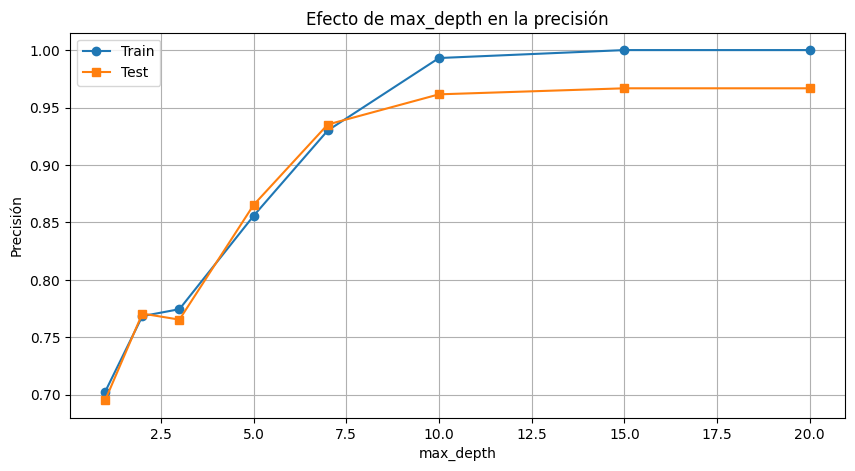

In [24]:
# Visualizar el efecto de max_depth
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores = []

for depth in depths_plot:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths_plot, train_scores, marker='o', label='Train')
plt.plot(depths_plot, test_scores, marker='s', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Precisión')
plt.title('Efecto de max_depth en la precisión')
plt.legend()
plt.grid(True)
plt.show()

### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C

In [25]:
# Experimentar con min_samples_split
min_samples_list = [2, 5, 10, 20, 50]
resultados_mss = []

for mss in min_samples_list:
    clf = DecisionTreeClassifier(criterion='gini', min_samples_split=mss, random_state=42)
    clf.fit(X_train, y_train)
    resultados_mss.append({
        'min_samples_split': mss,
        'Precisión Train': accuracy_score(y_train, clf.predict(X_train)),
        'Precisión Test': accuracy_score(y_test, clf.predict(X_test)),
        'Profundidad': clf.get_depth(),
        'Hojas': clf.get_n_leaves()
    })

df_mss = pd.DataFrame(resultados_mss)
print(df_mss)

   min_samples_split  Precisión Train  Precisión Test  Profundidad  Hojas
0                  2         1.000000        0.966725           14     73
1                  5         0.991357        0.956217           12     62
2                 10         0.976664        0.942207           11     49
3                 20         0.953328        0.931699           10     38
4                 50         0.891098        0.886165            8     19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [26]:
# Entrenar modelo final con los mejores hiperparámetros
clf_final = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=5, random_state=42)
clf_final.fit(X_train, y_train)

y_pred_final = clf_final.predict(X_test)
acc_final_test = accuracy_score(y_test, y_pred_final)
acc_final_train = accuracy_score(y_train, clf_final.predict(X_train))

print(f"Precisión Test  (Final): {acc_final_test:.4f}")
print(f"Precisión Train (Final): {acc_final_train:.4f}")
print("Profundidad:", clf_final.get_depth())
print("Número de hojas:", clf_final.get_n_leaves())

Precisión Test  (Final): 0.9335
Precisión Train (Final): 0.9283
Profundidad: 7
Número de hojas: 27


In [27]:
# Imprimir reporte de clasificación final
print(classification_report(y_test, y_pred_final, target_names=class_names))

              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C